In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from fuzzywuzzy import process

In [3]:
# ======================
# 1. Load the datasets
# ======================
before = pd.read_csv("BeforeAI.csv")
after = pd.read_csv("AfterAI.csv")

# ======================
# 2. Normalize column names
# ======================
def normalize_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[^a-z0-9]+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    return df

before = normalize_cols(before)
after = normalize_cols(after)

In [4]:
# ======================
# 3. Attempt fuzzy matching of columns
# ======================
before_cols = before.columns.tolist()
after_cols = after.columns.tolist()

mapping = {}
for col in after_cols:
    best_match, score = process.extractOne(col, before_cols)
    if score >= 85:  # threshold for high similarity
        mapping[col] = best_match

# Apply the mapping to after dataset
after = after.rename(columns=mapping)

In [5]:
# ======================
# 4. Determine common comparable columns
# ======================
common_cols = list(set(before.columns).intersection(set(after.columns)))

print("\n=== COMMON ALIGNED COLUMNS FOUND ===")
print(common_cols)
print("Total:", len(common_cols))

if len(common_cols) == 0:
    raise Exception("No common columns found! Lower threshold or inspect data manually.")


=== COMMON ALIGNED COLUMNS FOUND ===
['bwd iat min', 'fwd packet length min', 'flow iat std', 'bwd iat total', 'bwd psh flags', 'idle max', 'fwd psh flags', 'idle std', 'fwd iat max', 'subflow bwd bytes', 'fwd packets s', 'ece flag count', 'fwd packet length mean', 'down up ratio', 'cwe flag count', 'syn flag count', 'active mean', 'idle min', 'flow iat min', 'urg flag count', 'bwd urg flags', 'average packet size', 'fwd packet length std', 'subflow bwd packets', 'subflow fwd packets', 'bwd iat mean', 'fwd iat mean', 'bwd iat std', 'active std', 'destination port', 'flow bytes s', 'bwd header length', 'active min', 'fwd iat min', 'ack flag count', 'flow iat max', 'rst flag count', 'act data pkt fwd', 'fin flag count', 'fwd header length', 'psh flag count', 'total length of bwd packets', 'fwd avg bulk rate', 'bwd avg bulk rate', 'fwd packet length max', 'bwd packets s', 'subflow fwd bytes', 'active max', 'fwd iat std', 'label', 'flow iat mean', 'idle mean', 'fwd urg flags', 'fwd iat to

In [ ]:
# ======================
# 5. Reduce to common comparable subset
# ======================
before_aligned = before[common_cols]
after_aligned = after[common_cols]

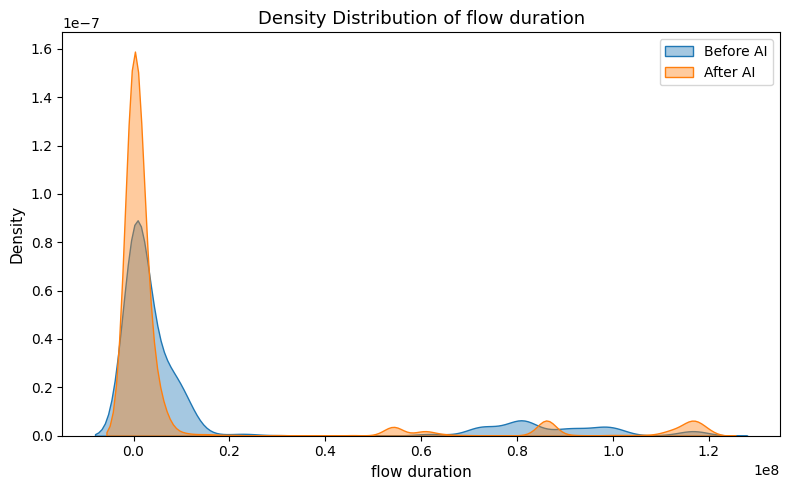

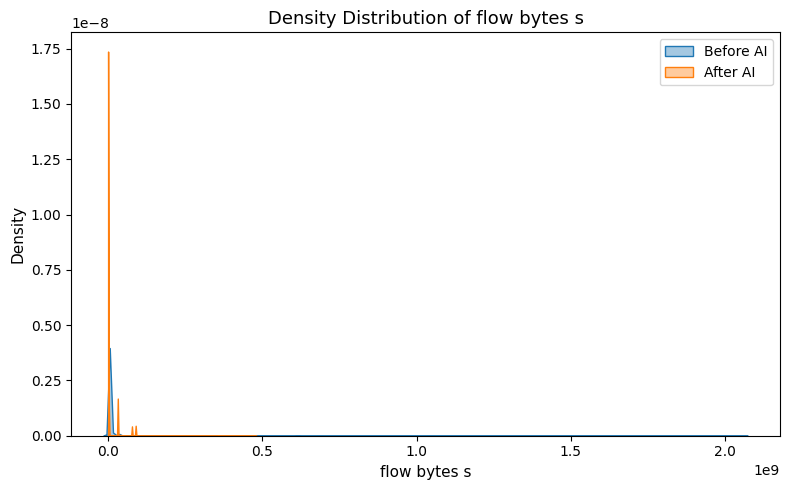

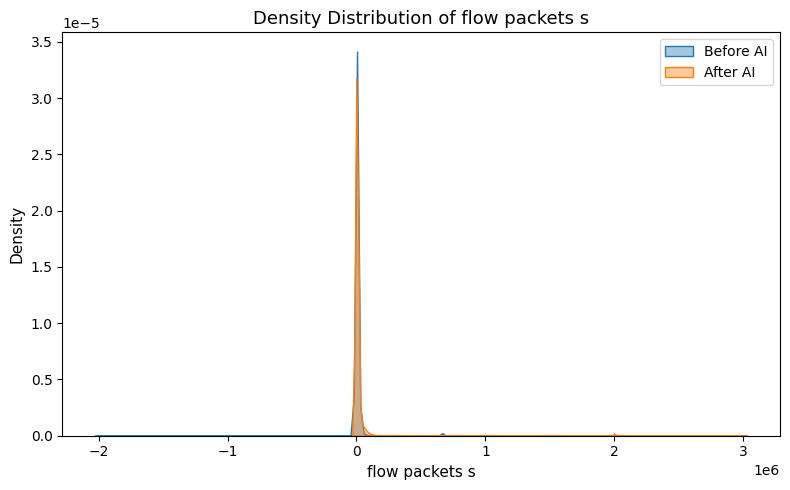

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['flow duration', 'flow bytes s', 'flow packets s']

for col in features:
    plt.figure(figsize=(8,5))
    sns.kdeplot(before_aligned[col], label="Before AI", fill=True, alpha=0.4)
    sns.kdeplot(after_aligned[col], label="After AI", fill=True, alpha=0.4)
    plt.title(f"Density Distribution of {col}", fontsize=13)
    plt.xlabel(col, fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.legend()
    plt.tight_layout()
    plt.show()

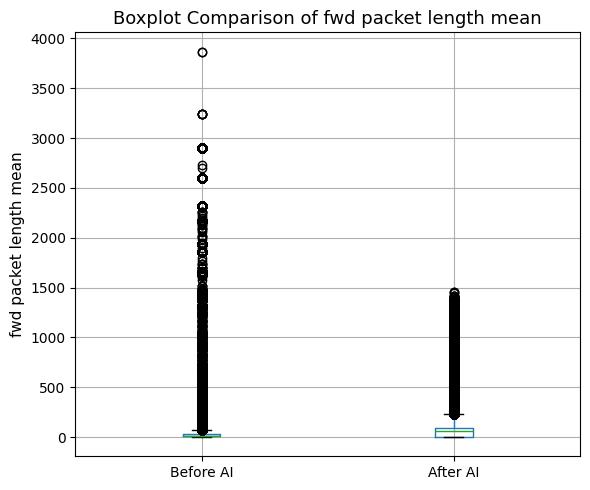

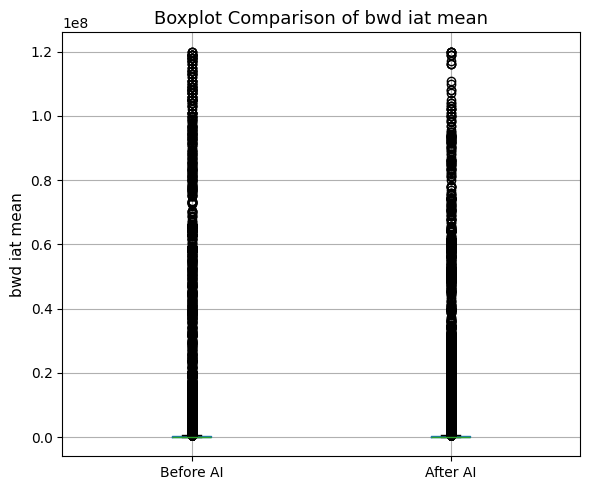

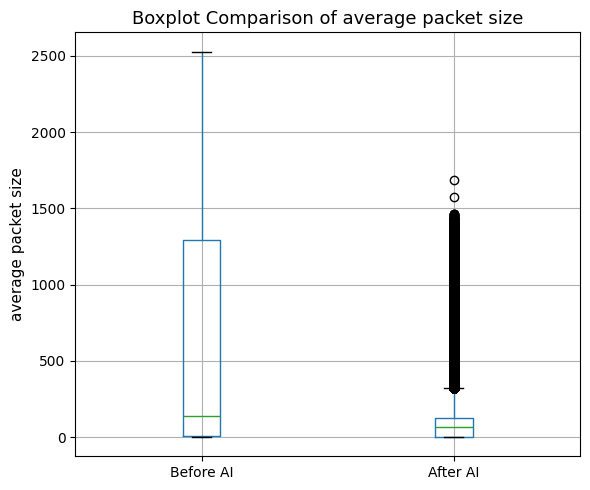

In [10]:
features = ['fwd packet length mean', 'bwd iat mean', 'average packet size']

for col in features:
    data = pd.DataFrame({
        'Before AI': before_aligned[col],
        'After AI': after_aligned[col]
    })
    plt.figure(figsize=(6,5))
    data.boxplot()
    plt.title(f"Boxplot Comparison of {col}", fontsize=13)
    plt.ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

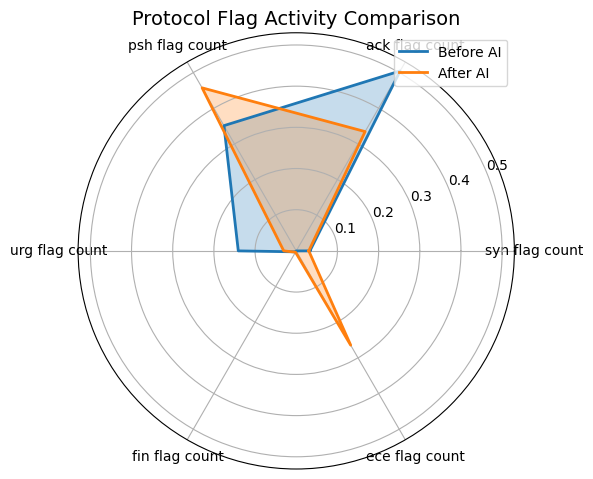

In [12]:
import numpy as np
import matplotlib.pyplot as plt

flags = ['syn flag count','ack flag count','psh flag count','urg flag count','fin flag count','ece flag count']

before_mean = before_aligned[flags].mean().values
after_mean = after_aligned[flags].mean().values

angles = np.linspace(0, 2*np.pi, len(flags), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

b_stats = np.concatenate((before_mean,[before_mean[0]]))
a_stats = np.concatenate((after_mean,[after_mean[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.plot(angles, b_stats, label="Before AI", linewidth=2)
ax.fill(angles, b_stats, alpha=0.25)
ax.plot(angles, a_stats, label="After AI", linewidth=2)
ax.fill(angles, a_stats, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(flags)
plt.title("Protocol Flag Activity Comparison", fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


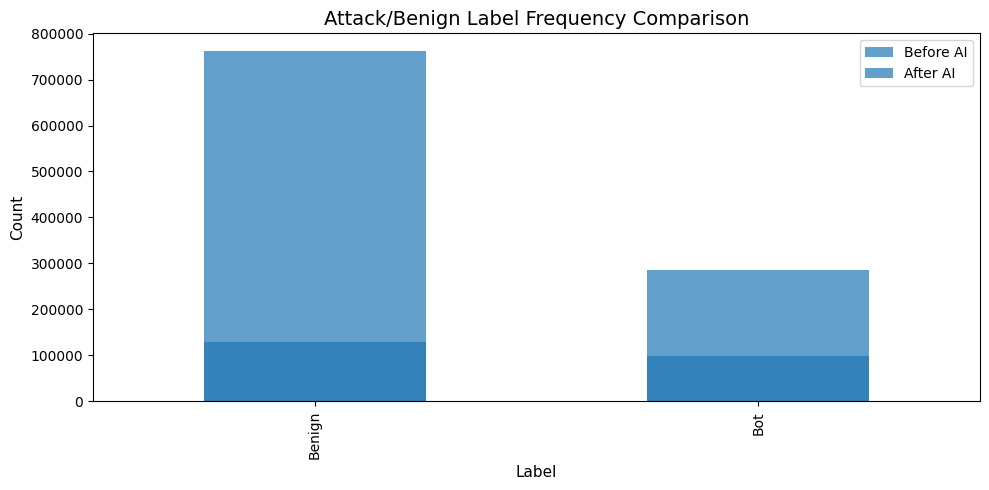

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
before_aligned['label'].value_counts().plot(kind='bar', alpha=0.7, label="Before AI")
after_aligned['label'].value_counts().plot(kind='bar', alpha=0.7, label="After AI")
plt.title("Attack/Benign Label Frequency Comparison", fontsize=14)
plt.ylabel("Count", fontsize=11)
plt.xlabel("Label", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


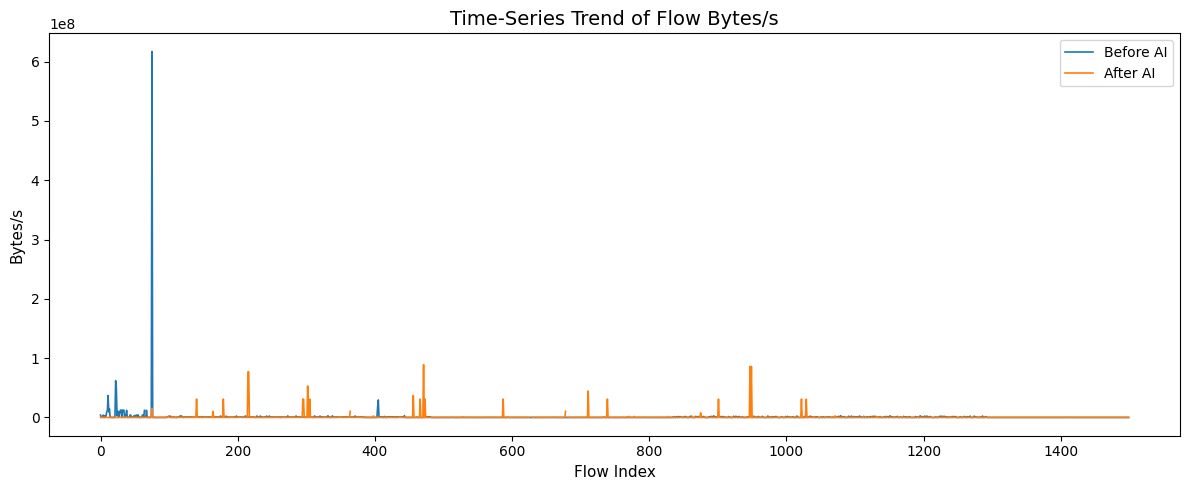

In [14]:
plt.figure(figsize=(12,5))
plt.plot(before_aligned['flow bytes s'].head(1500).reset_index(drop=True), label='Before AI', linewidth=1.2)
plt.plot(after_aligned['flow bytes s'].head(1500).reset_index(drop=True), label='After AI', linewidth=1.2)
plt.title("Time-Series Trend of Flow Bytes/s", fontsize=14)
plt.ylabel("Bytes/s", fontsize=11)
plt.xlabel("Flow Index", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()